# Sweden barrier-construction event study — Callaway–Sant'Anna DiD (Stata)

**Source.** `data/sweden/panel/assembled/event_study_panel.parquet`, built by
`python -m src.cli sweden data panel assemble`
(`src/regions/sweden/sources/panel/assemble.py`). For a general descriptive
tour of the *whole* long panel (grain, outcome coverage, all eight treatment
tiers, traffic/neighbourhood match rates), see
[`descriptive_statistics.ipynb`](descriptive_statistics.ipynb) (Python).
This notebook is scoped narrower and deeper: it builds the one CS-ready
analysis dataset, describes it, then actually estimates a Callaway &
Sant'Anna (2021) staggered-adoption event study and a covariate-augmented
ATT table — using real Stata (`csdid`/`drdid`, Rios-Avila, Sant'Anna &
Callaway) called from Python via StataCorp's own
[`pystata`](https://www.stata.com/python/pystata/) integration, not a
Python reimplementation.

**Outcome**: `meritvärde_z` — the one outcome in the panel constructed
specifically to be poolable across the full 1998–2019 SIRIS window (z-scored
separately on each side of the 2014/15 grading-scale reform; see
[`assessments.ipynb`](../../../src/experiments/sweden/assessments.ipynb) §3).
30,441 rows / 2,624 schools.

**Treatment**: road and rail barrier construction *combined* into one
treatment, matched at the **`protected`** tier (switched 2026-09-24). A
school is treated once it lies in a barrier's **protected area**:
- on the barrier's side of its road or track
- within 600m of it
- with its nearest point on that road beside the barrier's own stretch
  (±50m)

A school on the right side but further along the road is not protected;
nor is one nearer an unshielded bend of the same road.

The side comes from `src/regions/sweden/sources/_barrier_reference.py`: an
OpenStreetMap wall, walls on both sides, the barrier's own offset, a rail
barrier's recorded distance from its track, or the road running alongside.
Otherwise it is `unknown`, never assumed. Method and validation:
[`docs/data/sweden/barrier_matching.md`](../../../docs/data/sweden/barrier_matching.md).

A school is treated when `protected` under *either* `road` or `rail`; its
event time runs from whichever kind's construction came first. Two groups
are dropped rather than coded as controls (§1):
- treated schools whose every protecting barrier lacks a construction year
- untreated schools beside a barrier whose side is unknown, since they may
  in fact be protected

The Summary's dated notes record the earlier `same_route` and `same_side`
runs.

**Honesty note, not hidden**: `protected` is the most faithful treatment
definition and also the smallest. Only 42 schools have a usable treatment
year, and only 18 were built inside the observed 1998–2019 window (§1).
Covariate coverage is 20–40%. The estimates below are real output, but
several of them rest on one or two cohorts, so read the standard errors
and the pre-periods, not just the point estimates.

**What goes where.** As a rule: anything about the *whole* panel — grain,
coverage, all eight treatment tiers, a covariate source's match rate over
time — belongs in
[`descriptive_statistics.ipynb`](descriptive_statistics.ipynb), in Python,
even once that source is already joined into `panel`. This notebook only
ever describes the *already-collapsed*, CS-ready dataset (§3's Stata
`describe`/`summarize`/`tabstat`) and estimates on it; it never re-derives
panel-wide facts. One gap that follows directly from this rule:
`descriptive_statistics.ipynb` §6 profiles Cluster C's (traffic) match rate
by year but has no equivalent section for Cluster F (neighbourhood, used in
§5 below) — that diagnostic is missing there, not something to patch in
here.


## 1. Build the CS-ready analysis dataset (Python)


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import np, pd

from src.regions.sweden.sources.panel.shared import assembled_panel_path

panel = pd.read_parquet(assembled_panel_path())
print(f"{len(panel):,} panel rows loaded, {panel['skolenhetskod'].nunique():,} distinct schools")


557,200 panel rows loaded, 2,649 distinct schools


In [2]:
OUTCOME_NAME = "meritvärde_z"
MATCH_TIER = "protected"  # road/rail-combined tier, switched 2026-09-24: the school lies in a barrier's protected area -- same side AND beside the barrier's own stretch (docs/data/sweden/barrier_matching.md §7.1)

outcome = panel.loc[panel["outcome_name"] == OUTCOME_NAME].copy()
print(f"{len(outcome):,} rows for outcome_name == {OUTCOME_NAME!r}, "
      f"{outcome['skolenhetskod'].nunique():,} schools, "
      f"years {outcome['year'].min()}-{outcome['year'].max()}")

road_ever = outcome[f"road_ever_treated_{MATCH_TIER}"]
road_unknown = outcome[f"road_timing_unknown_{MATCH_TIER}"]
rail_ever = outcome[f"rail_ever_treated_{MATCH_TIER}"]
rail_unknown = outcome[f"rail_timing_unknown_{MATCH_TIER}"]

combined_ever = road_ever | rail_ever
combined_usable = (road_ever & ~road_unknown) | (rail_ever & ~rail_unknown)

both_kinds = (road_ever & ~road_unknown) & (rail_ever & ~rail_unknown)
print(f"\n{combined_ever.sum():,} rows ever-treated by road or rail ({MATCH_TIER}); "
      f"{both_kinds.sum():,} of those rows are near BOTH a road and a rail barrier with known timing "
      "-- combined event time uses whichever came first for these.")

# A school ever-treated only by kind(s) whose construction year is itself
# unknown (see schools.ipynb's `timing_unknown` finding) can't be placed in
# event time at all -- drop it rather than silently mis-code it as a control.
drop_mask = combined_ever & ~combined_usable
print(f"dropping {drop_mask.sum():,} rows ({outcome.loc[drop_mask, 'skolenhetskod'].nunique():,} schools): "
      "ever-treated but every matching barrier's construction year is unknown")
# Likewise a never-treated school beside a barrier whose side is unknown: it
# may be protected, so it is not a clean control either -- drop it too.
side_unknown = outcome[f"road_{MATCH_TIER}_unknown"] | outcome[f"rail_{MATCH_TIER}_unknown"]
unknown_mask = side_unknown & ~combined_ever
print(f"dropping {unknown_mask.sum():,} rows ({outcome.loc[unknown_mask, 'skolenhetskod'].nunique():,} schools): "
      "not treated, but beside a barrier whose side is unknown")
outcome = outcome.loc[~(drop_mask | unknown_mask)].copy()

# recompute per-kind usability directly on the filtered frame (positions shifted after the drop above)
road_year = outcome[f"road_first_treat_year_{MATCH_TIER}"].where(
    outcome[f"road_ever_treated_{MATCH_TIER}"] & ~outcome[f"road_timing_unknown_{MATCH_TIER}"]
)
rail_year = outcome[f"rail_first_treat_year_{MATCH_TIER}"].where(
    outcome[f"rail_ever_treated_{MATCH_TIER}"] & ~outcome[f"rail_timing_unknown_{MATCH_TIER}"]
)
# combined first-treatment year: the earlier of the two kinds' usable years (0 = never-treated, csdid's own sentinel)
combined_year = pd.concat([road_year, rail_year], axis=1).min(axis=1, skipna=True)

outcome["id"] = outcome["skolenhetskod"].astype("int64")
outcome["gvar"] = combined_year.fillna(0.0)

analysis = outcome[[
    "id", "year", "gvar", "value",
    "traffic_max_adt_500m",
    "neighbourhood_mean_net_income_tkr",
    "neighbourhood_share_eftergymnasial",
]].rename(columns={
    "value": "meritvarde_z",
    # the busiest counted road within 500m of the school (switched
    # 2026-09-24 from the single nearest segment, which is the protecting
    # barrier's own road for only ~42% of protected schools)
    "traffic_max_adt_500m": "traffic_max_adt",
    "neighbourhood_mean_net_income_tkr": "nbhd_income",
    "neighbourhood_share_eftergymnasial": "nbhd_edu_share",
})

n_treated_schools = analysis.loc[analysis["gvar"] > 0, "id"].nunique()
print(f"\nfinal analysis dataset: {len(analysis):,} rows, {analysis['id'].nunique():,} schools, "
      f"{n_treated_schools:,} with a usable combined treatment year")
print("\ncovariate coverage (share non-missing):")
print(analysis[["traffic_max_adt", "nbhd_income", "nbhd_edu_share"]].notna().mean())


30,441 rows for outcome_name == 'meritvärde_z', 2,622 schools, years 1998-2019

766 rows ever-treated by road or rail (protected); 0 of those rows are near BOTH a road and a rail barrier with known timing -- combined event time uses whichever came first for these.
dropping 250 rows (22 schools): ever-treated but every matching barrier's construction year is unknown
dropping 900 rows (79 schools): not treated, but beside a barrier whose side is unknown

final analysis dataset: 29,291 rows, 2,521 schools, 42 with a usable combined treatment year

covariate coverage (share non-missing):
traffic_max_adt    0.374006
nbhd_income        0.355672
nbhd_edu_share     0.212249
dtype: float64


`employment_rate` is deliberately excluded from the covariate set above: its
real coverage floor (2020) never overlaps this panel's 1998–2019 window at
all (0% real coverage, confirmed in `docs/data-status.md`), so including it
would just add a constant-missing column.


In [3]:
# `gvar` is a barrier-construction year, not constrained to fall inside the
# outcome panel's own 1998-2019 window -- worth checking directly rather
# than assuming every "treated" school actually has both a pre- and a
# post-period observed.
treated_gvar = analysis.loc[analysis["gvar"] > 0].groupby("id")["gvar"].first()
panel_min, panel_max = analysis["year"].min(), analysis["year"].max()

before_panel = int((treated_gvar < panel_min).sum())
after_panel = int((treated_gvar > panel_max).sum())
inside_panel = len(treated_gvar) - before_panel - after_panel

print(f"panel outcome window: {panel_min}-{panel_max}")
print(f"{len(treated_gvar)} schools with a usable combined treatment year:")
print(f"  construction before {panel_min} (no pre-period ever observed): {before_panel}")
print(f"  construction after {panel_max} (no post-period ever observed):  {after_panel}")
print(f"  construction inside the observed window:                       {inside_panel}")


panel outcome window: 1998-2019
42 schools with a usable combined treatment year:
  construction before 1998 (no pre-period ever observed): 3
  construction after 2019 (no post-period ever observed):  21
  construction inside the observed window:                       18


Only 18 of the 42 nominally treated schools have their construction year
inside the observed 1998–2019 outcome window. The other two groups don't
break the estimator (`csdid` simply never computes a group-time ATT for a
period it doesn't observe), but they shrink what "42 treated schools"
really buys:

- **3 schools built before 1998** have no pre-treatment period in the data,
  so there is no base period (`G-1`) to compare to. They contribute
  nothing to identification.
- **21 schools built after 2019**, half the nominal 42, are never observed
  post-treatment. They act only as not-yet-treated controls for earlier
  cohorts.
- That leaves **18 schools** driving both the pre-trend checks and the
  post-treatment ATTs below, spread over 11 construction years. Most
  cohorts are one or two schools, so a single school can move a
  group-time estimate.

## 2. Hand off to Stata


In [4]:
# StataCorp's own Python integration, shipped inside the Stata install itself
# (not on PyPI) -- adjust this path if Stata is installed somewhere else on
# your machine. Registers the %%stata cell magic used in every cell below.
STATA_UTILITIES = "/Applications/Stata/utilities"
if STATA_UTILITIES not in sys.path:
    sys.path.insert(0, STATA_UTILITIES)

from pystata import config

config.init("mp")  # edition matches this machine's license (StataMP); use "se"/"be" if yours differs



  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806386291
  Licensed to: Universität Basel
               WWZ

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [5]:
%%stata -d analysis -force
set processors 1
* csdid's bootstrap step is unstable under multi-core StataMP in some
* sandboxed/virtualized environments (segfaults observed in this repo's own
* CI-style sandbox) -- forcing single-threaded execution is the safe
* default; raise it back to `set processors 2` (or your machine's core
* count) once you've confirmed it's stable in your own environment.
xtset id year



. set processors 1
    The maximum number of processors or cores being used is changed from 2 to
    1.  It can be set to any number between 1 and 2

. * csdid's bootstrap step is unstable under multi-core StataMP in some
. * sandboxed/virtualized environments (segfaults observed in this repo's own
. * CI-style sandbox) -- forcing single-threaded execution is the safe
. * default; raise it back to `set processors 2` (or your machine's core
. * count) once you've confirmed it's stable in your own environment.
. xtset id year


Panel variable: id (unbalanced)
 Time variable: year, 1998 to 2019, but with gaps
         Delta: 1 unit

. 


## 3. Descriptive statistics on the analysis panel


In [6]:
%%stata
describe meritvarde_z gvar traffic_max_adt nbhd_income nbhd_edu_share
summarize meritvarde_z traffic_max_adt nbhd_income nbhd_edu_share

* one row per school: is it ever-treated (usable timing), and when
preserve
gen byte ever_treated = gvar > 0
bysort id (year): keep if _n == 1

count
local n_schools = r(N)
count if ever_treated
local n_treated = r(N)
di as text _n "distinct schools: " as result `n_schools'
di as text "ever-treated (usable combined timing): " as result `n_treated'

tabulate gvar if ever_treated, missing
restore



. describe meritvarde_z gvar traffic_max_adt nbhd_income nbhd_edu_share

Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
meritvarde_z    double  %10.0g                
gvar            double  %10.0g                
traffic_max_adt double  %10.0g                
nbhd_income     double  %10.0g                
nbhd_edu_share  double  %10.0g                

. summarize meritvarde_z traffic_max_adt nbhd_income nbhd_edu_share

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
meritvarde_z |     29,291   -.0035395    .9987971  -8.666742   4.123199
traffic_ma~t |     10,955      8349.2    10302.59          1      90000
 nbhd_income |     10,418     336.136    115.3836      129.9     3146.9
nbhd_edu_s~e |      6,217    .4209217    .1572876   .1138614   .8717949

. 
. *


. gen byte ever_treated = gvar > 0

. bysort id (year): keep if _n == 1
(26,770 observations deleted)

. 
. count
  2,521

. local n_schools = r(N)

. count if ever_treated
  42

. local n_treated = r(N)

. di as text _n "distinct schools: " as result `n_schools'

distinct schools: 2521

. di as text "ever-treated (usable combined timing): " as result `n_treated'
ever-treated (usable combined timing): 42

. 
. tabulate gvar if ever_treated, missing

       gvar |      Freq.     Percent        Cum.
------------+-----------------------------------
       1995 |          2        4.76        4.76
       1997 |          1        2.38        7.14
       1999 |          1        2.38        9.52
       2000 |          1        2.38       11.90
       2001 |          1        2.38       14.29
       2008 |          1        2.38       16.67
       2012 |          2        4.76       21.43
       2014 |          3        7.14       28.57
       2015 |          2        4.76       33.33
      


. 


In [7]:
%%stata
* covariate balance: treated vs. never-treated schools (row-level, not
* collapsed -- a simple descriptive check, not a formal balance test)
gen byte ever_treated = gvar > 0
tabstat traffic_max_adt nbhd_income nbhd_edu_share, by(ever_treated) stat(mean sd n) columns(statistics)
drop ever_treated



. * covariate balance: treated vs. never-treated schools (row-level, not
. * collapsed -- a simple descriptive check, not a formal balance test)
. gen byte ever_treated = gvar > 0

. tabstat traffic_max_adt nbhd_income nbhd_edu_share, by(ever_treated) stat(mea
> n sd n) columns(statistics)



Summary for variables: traffic_max_adt nbhd_income nbhd_edu_share
Group variable: ever_treated 

ever_treated |      Mean        SD         N
-------------+------------------------------
           0 |  8267.776  10325.73     10725
             |  336.3982  116.3199     10181
             |  .4212515  .1578682      6073
-------------+------------------------------
           1 |  12146.03  8334.549       230
             |  324.8743  62.30409       237
             |  .4070152  .1301704       144
-------------+------------------------------
       Total |    8349.2  10302.59     10955
             |   336.136  115.3836     10418
             |  .4209217  .1572876      6217
--------------------------------------------

. drop ever_treated

. 


**Coverage** over the 29,291-row analysis panel:
- traffic 37.4% (10,955 rows)
- neighbourhood income 35.6% (10,418)
- neighbourhood education 21.2% (6,217)

The traffic covariate is now `traffic_max_adt`, the busiest counted road
within 500m of the school (switched 2026-09-24 from the single nearest
segment; it also no longer carries Trafik's 999,998 "no value"
placeholder).

**Cohorts.** The `tabulate gvar` above shows why the event-study standard
errors below are fragile. The 42 treated schools spread over 18
construction years, almost all with 1–3 schools; only 2022 (8) and 2023
(6) are larger, and both are after the outcome window ends.

**Balance.** Treated schools sit by busier roads (12,146 vs. 8,268
vehicles/day), in slightly lower-income (325 vs. 336 tkr) and
slightly less-educated (40.7% vs. 42.1% post-secondary) neighbourhoods
than never-treated schools. That is consistent with the barrier-siting
endogeneity `covariates.md` flags (walls go where modelled noise is
high) and is part of the motivation for §5's covariate-augmented specs.

## 4. Callaway–Sant'Anna event study — simple DiD, no controls


In [8]:
%%stata -gw 7 -gh 4.5
quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple



. quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(drip
> w)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |

   .3374897   .1554815     2.17   0.030     .0327515    .6422278
------------------------------------------------------------------------------



. 


The unconditional ATT is **0.337 SD** on `meritvärde_z` (SE 0.155,
p=0.030, 95% CI 0.03 to 0.64): positive and significant at 5%. On its face
this says schools in a barrier's protected area improve after
construction. Read it against §1's sample, though: it rests on the 18
schools built inside the window, in cohorts of one or two, and §4's pre-trend
check and §8's falsification check below both qualify it.

`csdid` itself is run with `quietly`: its default display is the *full*
group-time ATT(g,t) array (one block per treatment cohort, every
comparison period) — real output, but a wall of numbers that answers a
different question than "what's the overall effect." `estat simple` above
is the single overall ATT (the Callaway–Sant'Anna analogue of a textbook
2x2 DiD coefficient), aggregating every group-time ATT(g,t) with the
estimator's default weighting. The event-study plot below breaks that same
estimate out by event time instead, which is what actually lets you check
for pre-trends.



. estat event, window(-8 8) estore(cs_event)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |  -.0403642   .0299142    -1.35   0.177    -.0989949    .0182665
    Post_avg |   .3094259   .0597121     5.18   0.000     .1923924    .4264594
         Tm8 |  -.0369518   .1468331    -0.25   0.801    -.3247393    .2508357
         Tm7 |   .0002497   .1122087     0.00   0.998    -.2196754    .2201748
         Tm6 |   .1980352   .1236742     1.60   0.109    -.0443617    .4404322
         Tm5 |  -.2225981   .0987666    -2.25   0.024     -.416177   -.0290191
         Tm4 |   .1483173   .0981128     1.51   0.131    -.0439801    .3406148
         Tm3 |  -.0916282    .141386    -0.65   0.517    -.3687397    .1854833
         Tm2 |  -.2363241   .1135027    -2.08   0.037    -.4587853   -.0138628
         Tm1 |  -.0820136   .0907604    -0.90   0.36


. event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
>     together plottype(scatter) ciplottype(rcap) default_look ///
>     graph_opt(xtitle("Event time (years since barrier construction)") ///
>     ytitle("ATT on meritvärde_z") ///
>     title("Callaway-Sant'Anna event study: road+rail combined, protected matc
> h") ///
>     xlabel(-8(2)8) legend(off))



. 


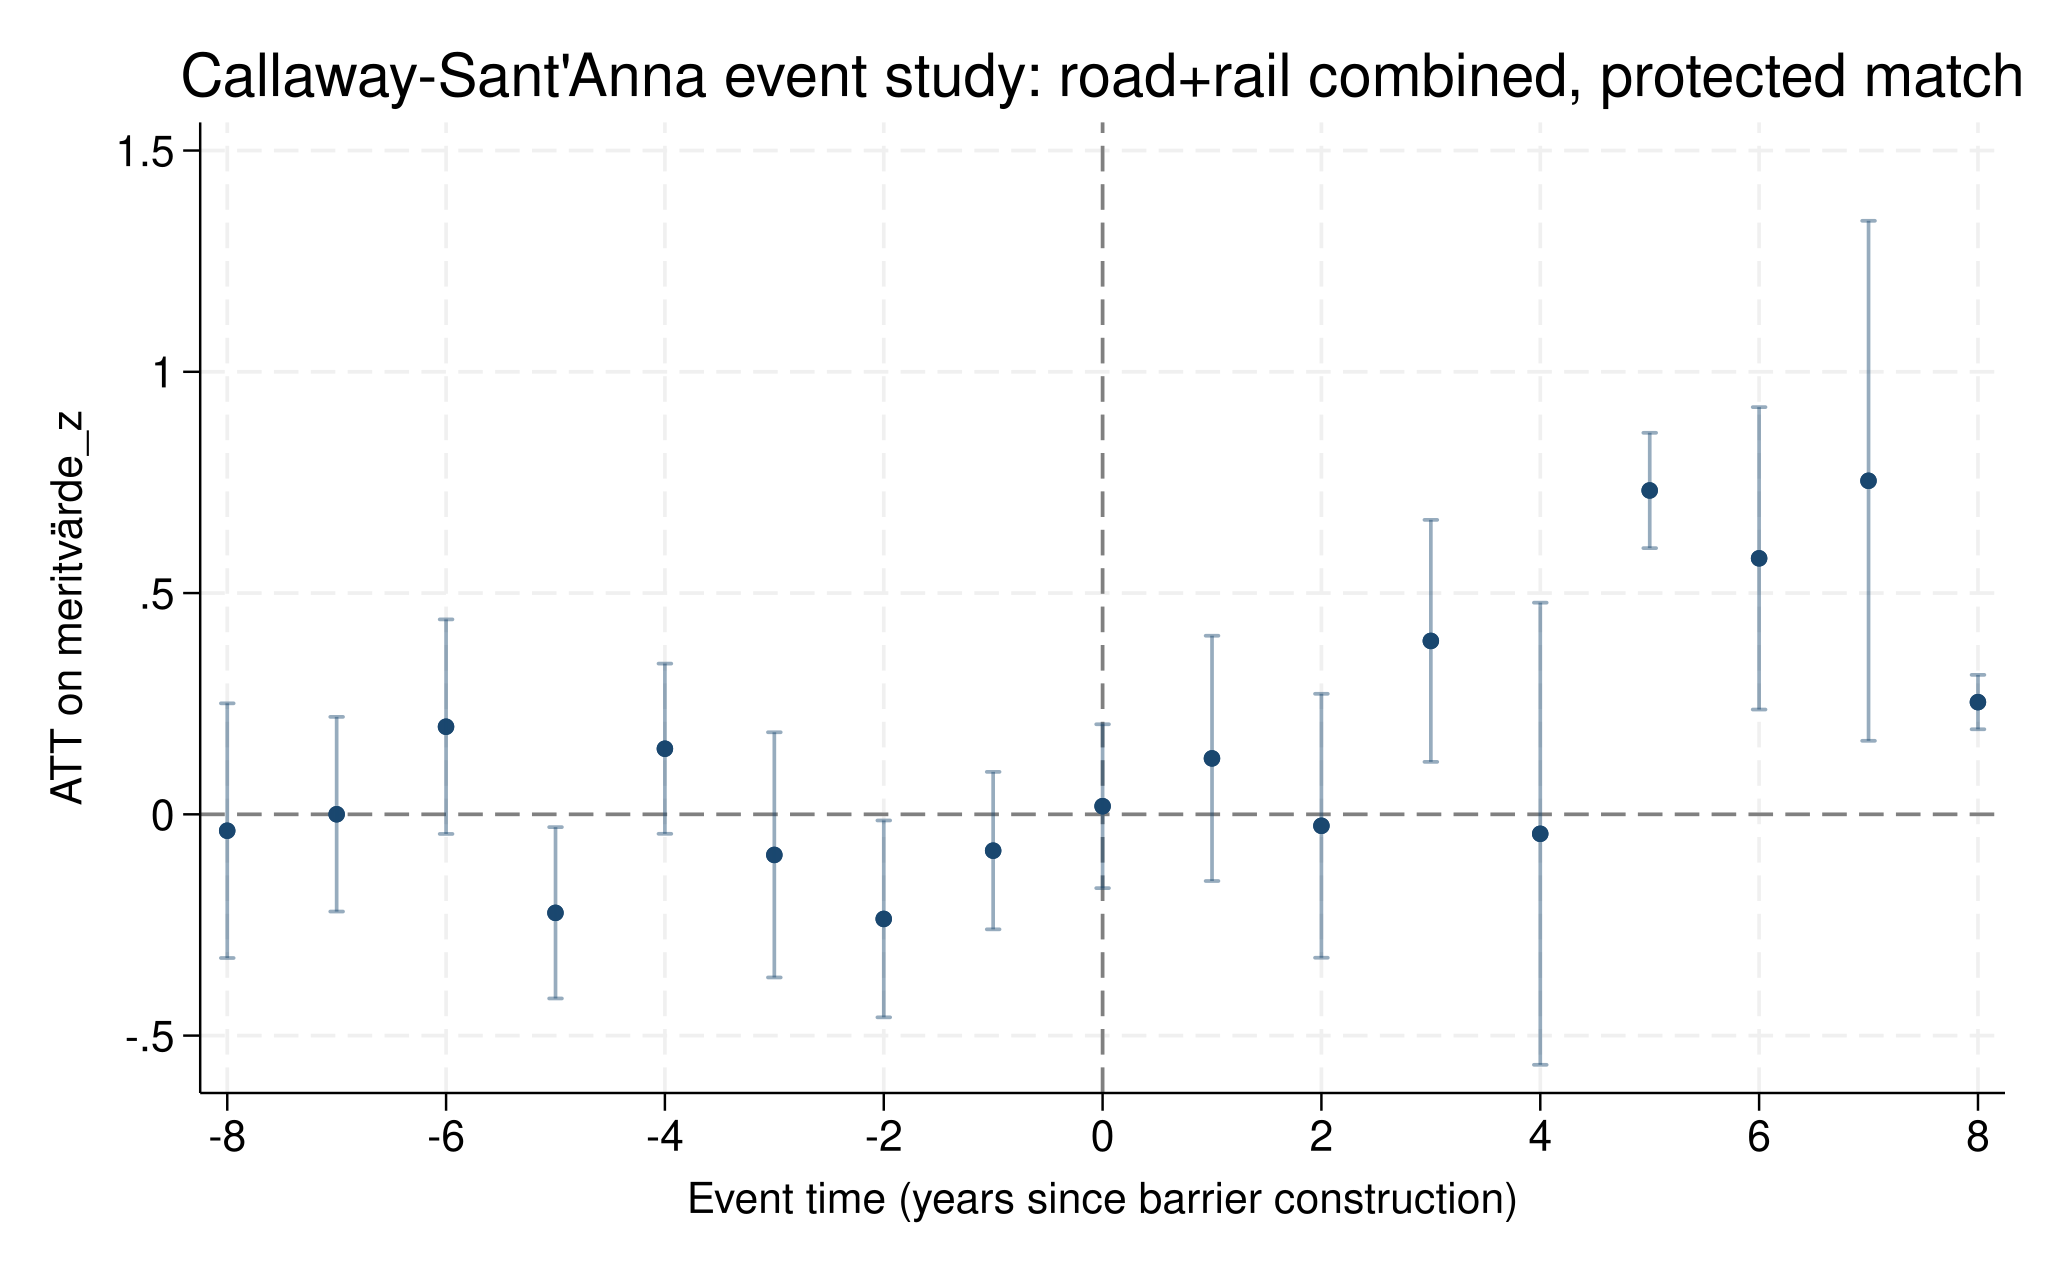

In [9]:
%%stata -gw 8 -gh 5
estat event, window(-8 8) estore(cs_event)
event_plot cs_event, stub_lag(Tp#) stub_lead(Tm#) trimlead(8) trimlag(8) ///
    together plottype(scatter) ciplottype(rcap) default_look ///
    graph_opt(xtitle("Event time (years since barrier construction)") ///
    ytitle("ATT on meritvärde_z") ///
    title("Callaway-Sant'Anna event study: road+rail combined, protected match") ///
    xlabel(-8(2)8) legend(off))


**Pre-trends.** `Pre_avg` (the average of Tm1–Tm8) is -0.040 (SE 0.030,
p=0.177), not significant on average. But two individual pre-period
coefficients are: `Tm5` (-0.223, p=0.024) and `Tm2` (-0.236, p=0.037).
Treated schools were dipping relative to controls before construction.
Part of the positive post-period estimate may therefore be recovery from
that dip rather than a barrier effect.

**Post-period.** `Post_avg` is 0.309 (SE 0.060, p<0.001), driven by
`Tp3` (0.392, p=0.005) and `Tp5`–`Tp8`. The late coefficients have
implausibly small standard errors: `Tp5` 0.732 with SE 0.066, `Tp8` 0.254
with SE 0.031. Standard errors that small at the edge of the window mean
those periods are identified off one or two cohorts, where `csdid`'s
analytic SE understates the uncertainty. `Post_avg`'s p-value inherits
that, so it is not a reliable measure of precision. `Tp0`–`Tp2` are all
insignificant.

One technical note on reading `Tm1`–`Tm8`: `csdid`'s default ("short gap")
pre-treatment ATTs compare each period `T-1` to `T`, not to the cohort's
own `G-1`. They are a period-by-period placebo test, not a comparison to a
single fixed reference. (`long2` would reanchor every pre-treatment ATT to
`G-1` instead, closer to a textbook event-study normalization, though even
then `csdid` won't report a point at `T=G-1` itself, since that
comparison is trivially zero.) Worth deciding explicitly which convention
this notebook wants if the plot is later used to argue for parallel
pre-trends.

## 5. Table with increasing controls


Callaway & Sant'Anna's doubly-robust estimator (`method(dripw)`, the
default) takes covariates directly on the `csdid` command line — they enter
both an outcome-regression and a propensity-score model for each (g,t) pair,
not as a single pooled regression coefficient, so there's no single "the
coefficient on income" to report as a table row the way a standard OLS
table would. What *is* comparable across specs is the aggregated overall
ATT (`estat simple`) — the increasing-controls analogue here is re-running
the whole group-time ATT array with a growing covariate set and comparing
that one summary number spec to spec. (`eststo`/`esttab` don't work
directly on `csdid`'s stored estimates — its `e(b)` holds the full
internal group-time weight-parameter array, not just the aggregated ATT —
so the table below is built by hand from `estat simple`'s `r(table)`,
which is the pattern used in the `csdid` Stata Journal article itself.) A
covariate with missing values drops any (g,t) pair-comparison where it's
unobserved for one of the two periods being compared, which is why `N`
shrinks spec to spec (see §1's coverage numbers) — real attrition, not a
bug.


In [10]:
%%stata
matrix results = J(4, 4, .)
matrix colnames results = ATT SE z N

quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[1,1] = b[1,1]
matrix results[1,2] = b[2,1]
matrix results[1,3] = b[3,1]
matrix results[1,4] = e(N)

quietly csdid meritvarde_z traffic_max_adt, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[2,1] = b[1,1]
matrix results[2,2] = b[2,1]
matrix results[2,3] = b[3,1]
matrix results[2,4] = e(N)

quietly csdid meritvarde_z traffic_max_adt nbhd_income, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[3,1] = b[1,1]
matrix results[3,2] = b[2,1]
matrix results[3,3] = b[3,1]
matrix results[3,4] = e(N)

quietly csdid meritvarde_z traffic_max_adt nbhd_income nbhd_edu_share, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix results[4,1] = b[1,1]
matrix results[4,2] = b[2,1]
matrix results[4,3] = b[3,1]
matrix results[4,4] = e(N)

matrix rownames results = "No controls" "+ Traffic" "+ Traffic, income" "+ Traffic, income, education"
matrix list results, format(%9.3f)



. matrix results = J(4, 4, .)

. matrix colnames results = ATT SE z N

. 
. quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(drip
> w)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .3374897   .1554815     2.17   0.030     .0327515    .6422278
------------------------------------------------------------------------------


...


. estat simple
Average Treatment Effect on Treated
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0656124   .1684864    -0.39   0.697    -.3958397     .264615
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix results[3,1] = b[1,1]

. matrix results[3,2] = b[2,1]

. matrix results[3,3] = b[3,1]

. matrix results[3,4] = e(N)

. 
. quietly csdid meritvarde_z traffic_max_adt nbhd_income nbhd_edu_share, ivar(i
> d) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .0426663   .1433892     0.30   0.766    -.2383713    .3237039
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix results[4,1] = b[1,1]

. matrix results[4,2] = b[2,1]

. matrix results[4,3] = b[3,1]

. matrix results[4,4] = e(N)

. 
. matrix rownames results = "No controls" "+ Traffic" "+ Traffic, income" "+ Tr
> affic, income, education"

. matrix list results, format(%9.3f)

results[4,4]
                    ATT         SE          z          N
 No controls      0.337      0.155      2.171  28915.000
   + Traffic      0.196      0.174      1.126  10780.000
+ Traffic,~e     -0.066      0.168     -0.389   4471.000
+ Traffic,~n      0.043      0.143      0.298   2615.000

. 


The ATT falls steadily as controls are added:

| controls | ATT | SE | p | N |
|---|---|---|---|---|
| none | 0.337 | 0.155 | 0.030 | 28,915 |
| + traffic | 0.196 | 0.174 | 0.260 | 10,780 |
| + traffic, income | -0.066 | 0.168 | 0.697 | 4,471 |
| + traffic, income, education | 0.043 | 0.143 | 0.766 | 2,615 |

The sample shrinks by 91% along the way, so the rows are not estimated on
the same schools. The decline is at least as consistent with the
covariate-complete subsample being a different slice of schools (more
urban, better instrumented) as with the controls removing confounding.
Either way, the headline 0.337 does not survive any controlled
specification, and every controlled row's 95% CI spans zero. A
same-sample check (re-running the no-controls spec on the complete-case
rows, as the Florida notebook does) would separate the two readings. It
is not run here yet; see the Summary's open items.

## 6. Weighting: the score vs. the regression

Two different, non-substitutable levers (see the discussion this section
operationalizes): **weighting the score** (`meritvärde_zw`, §3b of
[`assessments.ipynb`](../../../src/experiments/sweden/assessments.ipynb) —
standardises against a student-weighted mean/std instead of a
school-weighted one) only changes what "1 SD" means; **weighting the
regression** (`csdid`'s own `[iweight=antal_elever]`, confirmed to be a
real, documented option — internally treated as a `pweight`, so it flows
through the actual ATT(g,t) computation, not just a display artifact)
changes which schools drive the estimate, answering "effect per treated
*student*" instead of "effect per treated *school*". The table below runs
all four combinations on the same estimating sample.


In [11]:
# meritvärde_zw and antal_elever are separate outcome_name rows in `panel`
# (built by `stitch_meritvarde` -- see assessments.ipynb §3b), not columns
# on `analysis` -- pull and merge them in by (id, year).
zw_outcome = panel.loc[panel["outcome_name"] == "meritvärde_zw", ["skolenhetskod", "year", "value"]].rename(
    columns={"skolenhetskod": "id", "value": "meritvarde_zw"})
zw_outcome["id"] = zw_outcome["id"].astype("int64")

# `antal_elever` itself has the same år-2016 doubled-header anomaly as
# meritvärde (assemble.py's `ANTAL_ELEVER_2016_COLUMN`) -- combine both
# raw-melted variants the same way, or 2016 silently gets a missing weight.
elever_raw = panel.loc[
    panel["outcome_name"].isin(["antal_elever", "inklusive_okänd_bakgrund_antal_elever"]),
    ["skolenhetskod", "year", "outcome_name", "value"],
]
elever_outcome = elever_raw.pivot_table(index=["skolenhetskod", "year"], columns="outcome_name", values="value").reset_index()
elever_outcome["antal_elever"] = elever_outcome["antal_elever"].combine_first(
    elever_outcome.get("inklusive_okänd_bakgrund_antal_elever")
)
elever_outcome = elever_outcome.rename(columns={"skolenhetskod": "id"})[["id", "year", "antal_elever"]]
elever_outcome["id"] = elever_outcome["id"].astype("int64")

weighting = analysis.merge(zw_outcome, on=["id", "year"], how="left").merge(elever_outcome, on=["id", "year"], how="left")
print(f"{len(weighting):,} rows (same as `analysis`); "
      f"meritvarde_zw coverage {weighting['meritvarde_zw'].notna().mean():.1%}, "
      f"antal_elever coverage {weighting['antal_elever'].notna().mean():.1%}")


29,291 rows (same as `analysis`); meritvarde_zw coverage 100.0%, antal_elever coverage 100.0%


In [12]:
%%stata -d weighting -force
xtset id year
matrix wresults = J(4, 4, .)
matrix colnames wresults = ATT SE z N

quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[1,1] = b[1,1]
matrix wresults[1,2] = b[2,1]
matrix wresults[1,3] = b[3,1]
matrix wresults[1,4] = e(N)

* weighted csdid calls are ~20x slower than unweighted (~4 min each,
* timed in isolation) -- split from the weighted calls below into their
* own cell so a slow run doesn't blow one shared cell-level timeout.
quietly csdid meritvarde_zw, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[3,1] = b[1,1]
matrix wresults[3,2] = b[2,1]
matrix wresults[3,3] = b[3,1]
matrix wresults[3,4] = e(N)



. xtset id year



Panel variable: id (unbalanced)
 Time variable: year, 1998 to 2019, but with gaps
         Delta: 1 unit

. matrix wresults = J(4, 4, .)

. matrix colnames wresults = ATT SE z N

. 
. quietly csdid meritvarde_z, ivar(id) time(year) gvar(gvar) notyet method(drip
> w)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .3374897   .1554815     2.17   0.030     .0327515    .6422278
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[1,1] = b[1,1]

. matrix wresults[1,2] = b[2,1]

. matrix wresults[1,3] = b[3,1]

. matrix wresults[1,4] = e(N)

. 
. * weighted csdid calls are ~20x slower than unweighted (~4 min each,
. * timed in isolation) -- split from the weighted calls below into their
. * own cell so a slow run doesn't blow one shared cell-level timeout.
. quietly csdid meritvarde_zw, ivar(id) time(year) gvar(gvar) notyet method(dri
> pw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   .3846994   .1757627     2.19   0.029     .0402108     .729188
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix wresults[3,1] = b[1,1]

. matrix wresults[3,2] = b[2,1]

. matrix wresults[3,3] = b[3,1]

. matrix wresults[3,4] = e(N)

. 


In [13]:
# The two regression-weighted `csdid` calls are ~20x slower than the
# unweighted ones (several minutes each here), so they are opt-in. With the
# flag off, their rows in the table below stay missing (".").
RUN_WEIGHTED_REGRESSION = False

WEIGHTED_REGRESSION = """
quietly csdid meritvarde_z [iweight=antal_elever], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[2,1] = b[1,1]
matrix wresults[2,2] = b[2,1]
matrix wresults[2,3] = b[3,1]
matrix wresults[2,4] = e(N)

quietly csdid meritvarde_zw [iweight=antal_elever], ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix wresults[4,1] = b[1,1]
matrix wresults[4,2] = b[2,1]
matrix wresults[4,3] = b[3,1]
matrix wresults[4,4] = e(N)
"""
if RUN_WEIGHTED_REGRESSION:
    from pystata import stata

    stata.run(WEIGHTED_REGRESSION)
else:
    print("Skipped the two regression-weighted estimates; set RUN_WEIGHTED_REGRESSION = True to run them.")

Skipped the two regression-weighted estimates; set RUN_WEIGHTED_REGRESSION = True to run them.


In [14]:
%%stata
* continues the same Stata session: `wresults` holds the unweighted rows,
* plus the weighted ones when RUN_WEIGHTED_REGRESSION is on.
* Stata matrix row/column names are capped at 32 characters (confirmed by
* testing directly -- the first execution attempt failed with "invalid
* name" on a 33-char name, not because of any punctuation).
matrix rownames wresults = "Unweighted score, unwtd reg" "Unweighted score, wtd reg" "Weighted score, unwtd reg" "Weighted score, wtd reg"
matrix list wresults, format(%9.3f)


. * continues the same Stata session: `wresults` holds the unweighted rows,
. * plus the weighted ones when RUN_WEIGHTED_REGRESSION is on.
. * Stata matrix row/column names are capped at 32 characters (confirmed by
. * testing directly -- the first execution attempt failed with "invalid
. * name" on a 33-char name, not because of any punctuation).
. matrix rownames wresults = "Unweighted score, unwtd reg" "Unweighted score, w
> td reg" "Weighted score, unwtd reg" "Weighted score, wtd reg"

. matrix list wresults, format(%9.3f)

wresults[4,4]
                    ATT         SE          z          N
Unweighted~g      0.337      0.155      2.171  28915.000
Unweighted~g          .          .          .          .
Weighted s~g      0.385      0.176      2.189  28915.000
Weighted s~g          .          .          .          .

. 


Weighting the *score* (`meritvärde_zw`) moves the unweighted-regression
ATT from 0.337 to 0.385 (SE 0.176, p=0.029), a modest +14%; both stay
significant at 5%. The two *regression-weighted* rows are blank: those
`csdid` calls are ~20x slower and now opt-in (`RUN_WEIGHTED_REGRESSION`
above). The earlier `same_side` run found regression-weighting cut the ATT
by about a third, so set the flag before citing an "effect per treated
student".

## 7. Alternative outcome dimensions

Three more real, available outcomes at the same `(skolenhetskod, year)`
grain, none of which have been touched by any notebook so far — all
stitched in `assemble.py` and verified in
[`assessments.ipynb`](../../../src/experiments/sweden/assessments.ipynb)
§3b:

- **`meritvärde_residual_z`** — SALSA's own composition-adjusted
  value-added residual (actual meritvärde minus a model-predicted value
  given each school's parental-education/immigrant-share/sex mix),
  z-scored. **Caveat, not just a data-coverage footnote**: this residual
  is *already* adjusted for socioeconomic composition. If barrier
  construction itself shifts who enrols (sorting toward or away from a
  now-quieter area), SALSA's own adjustment could partial out exactly that
  channel — useful as a robustness/mechanism check, risky as a primary
  outcome. SALSA also covers fewer school-years than `meritvärde_z`
  (§1 already showed this skews toward larger schools), so the sample
  here is a real subset, not the full one.
- **`andel_uppnått_kunskapskraven_combined`** — pass rate (share meeting
  the knowledge requirements in every subject), a raw 0–100 share, not
  z-scored (no scale break to correct for).
- **`andel_behörig_combined`** — eligibility for upper-secondary school,
  same treatment.

These test a different part of the achievement distribution than the
continuous, GPA-like `meritvärde_z` (more sensitive to the middle/top) —
the pass-rate/eligibility shares probe the bottom, pass/fail margin.


In [15]:
def _pull_outcome(name: str, colname: str) -> pd.DataFrame:
    out = panel.loc[panel["outcome_name"] == name, ["skolenhetskod", "year", "value"]].rename(
        columns={"skolenhetskod": "id", "value": colname}
    )
    out["id"] = out["id"].astype("int64")
    return out

alt_outcomes = (
    analysis[["id", "year", "gvar"]]
    .merge(_pull_outcome("meritvärde_residual_z", "meritvarde_residual_z"), on=["id", "year"], how="left")
    .merge(_pull_outcome("andel_uppnått_kunskapskraven_combined", "pass_rate"), on=["id", "year"], how="left")
    .merge(_pull_outcome("andel_behörig_combined", "eligibility"), on=["id", "year"], how="left")
)
for col in ("meritvarde_residual_z", "pass_rate", "eligibility"):
    n_rows = alt_outcomes[col].notna().sum()
    n_treated = alt_outcomes.loc[alt_outcomes[col].notna() & (alt_outcomes["gvar"] > 0), "id"].nunique()
    print(f"{col}: {n_rows:,} / {len(alt_outcomes):,} rows real ({n_rows / len(alt_outcomes):.1%}), "
          f"{n_treated} treated schools with at least one real value")


meritvarde_residual_z: 28,086 / 29,291 rows real (95.9%), 42 treated schools with at least one real value


pass_rate: 28,459 / 29,291 rows real (97.2%), 42 treated schools with at least one real value
eligibility: 28,865 / 29,291 rows real (98.5%), 42 treated schools with at least one real value


In [16]:
%%stata -d alt_outcomes -force
xtset id year
matrix aresults = J(3, 4, .)
matrix colnames aresults = ATT SE z N

quietly csdid meritvarde_residual_z, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[1,1] = b[1,1]
matrix aresults[1,2] = b[2,1]
matrix aresults[1,3] = b[3,1]
matrix aresults[1,4] = e(N)

quietly csdid pass_rate, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[2,1] = b[1,1]
matrix aresults[2,2] = b[2,1]
matrix aresults[2,3] = b[3,1]
matrix aresults[2,4] = e(N)

quietly csdid eligibility, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat simple
matrix b = r(table)
matrix aresults[3,1] = b[1,1]
matrix aresults[3,2] = b[2,1]
matrix aresults[3,3] = b[3,1]
matrix aresults[3,4] = e(N)

* Stata matrix row/column names are capped at 32 characters (confirmed by
* testing directly -- keep it short, not just punctuation-free).
matrix rownames aresults = "meritvarde_residual_z (SALSA)" "pass_rate (pct points)" "eligibility (pct points)"
matrix list aresults, format(%9.3f)



. xtset id year



Panel variable: id (unbalanced)
 Time variable: year, 1998 to 2019, but with gaps
         Delta: 1 unit

. matrix aresults = J(3, 4, .)

. matrix colnames aresults = ATT SE z N

. 
. quietly csdid meritvarde_residual_z, ivar(id) time(year) gvar(gvar) notyet me
> thod(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple


Average Treatment Effect on Treated


...


. matrix b = r(table)

. matrix aresults[2,1] = b[1,1]

. matrix aresults[2,2] = b[2,1]

. matrix aresults[2,3] = b[3,1]

. matrix aresults[2,4] = e(N)

. 
. quietly csdid eligibility, ivar(id) time(year) gvar(gvar) notyet method(dripw
> )


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat simple
Average Treatment Effect on Treated


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |   1.424201    3.12836     0.46   0.649    -4.707272    7.555673
------------------------------------------------------------------------------



. matrix b = r(table)

. matrix aresults[3,1] = b[1,1]

. matrix aresults[3,2] = b[2,1]

. matrix aresults[3,3] = b[3,1]

. matrix aresults[3,4] = e(N)

. 
. * Stata matrix row/column names are capped at 32 characters (confirmed by
. * testing directly -- keep it short, not just punctuation-free).
. matrix rownames aresults = "meritvarde_residual_z (SALSA)" "pass_rate (pct po
> ints)" "eligibility (pct points)"

. matrix list aresults, format(%9.3f)

aresults[3,4]
                     ATT         SE          z          N
meritvarde_re
     sidual_z(
       SALSA)      0.737      0.270      2.729  27701.000
 pass_rate ~)      3.202      4.535      0.706  28086.000
 eligibilit~)      1.424      3.128      0.455  28500.000

. 


The alternative outcomes split:

- **SALSA's composition-adjusted residual is +0.737 SD** (SE 0.270,
  p=0.006). That is larger than the main estimate (0.337), not smaller.
  This is the outcome §7's intro flags as a bad-control risk. SALSA
  adjusts for exactly the enrolled-composition channel that §8 below finds
  moving after construction, so a larger adjusted effect is what you'd see
  if composition moved *against* achievement. That is what §8 shows.
- **The extensive-margin shares are null:** pass rate +3.2 pct. points
  (SE 4.5, p=0.480), eligibility +1.4 points (SE 3.1, p=0.649). The
  standard errors are large on 42 treated schools, so these rule out
  little.

No multiple-testing correction is applied across the four outcomes
(`meritvärde_z`, the residual and the two shares).

## 8. Falsification check: does the enrolled student body itself shift at event time 0?

A sharper compositional-balance check than §1's neighbourhood
(DeSO-area) income/education tabstat: `bakgrundsinformation_
föräldrarnas_genomsnittliga_utb_nivå` (parents' average education level)
and `bakgrundsinformation_andel_pojkar` (share boys) describe the *actual
enrolled student body*, same grain as `meritvärde_z`, sitting unused in
`panel` since they're SALSA columns nobody had pulled out. Treating them
as event-study "outcomes" with the exact same `gvar`/`id` structure as
the main analysis directly tests whether who attends a soon-to-be-treated
school is already changing before construction (an identification threat
— and also the channel §7's SALSA-residual caveat worries about) rather
than asserting it isn't.


In [17]:
composition = (
    analysis[["id", "year", "gvar"]]
    .merge(_pull_outcome("bakgrundsinformation_föräldrarnas_genomsnittliga_utb_nivå", "parent_edu"), on=["id", "year"], how="left")
    .merge(_pull_outcome("bakgrundsinformation_andel_pojkar", "share_boys"), on=["id", "year"], how="left")
)
for col in ("parent_edu", "share_boys"):
    n_rows = composition[col].notna().sum()
    print(f"{col}: {n_rows:,} / {len(composition):,} rows real ({n_rows / len(composition):.1%})")


parent_edu: 28,086 / 29,291 rows real (95.9%)
share_boys: 28,086 / 29,291 rows real (95.9%)


In [18]:
%%stata -d composition -force
xtset id year
di as text _n "=== parent_edu (parents' average education level) ==="
quietly csdid parent_edu, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)

di as text _n "=== share_boys (share male students) ==="
quietly csdid share_boys, ivar(id) time(year) gvar(gvar) notyet method(dripw)
estat event, window(-8 8)



. xtset id year



Panel variable: id (unbalanced)
 Time variable: year, 1998 to 2019, but with gaps
         Delta: 1 unit

. di as text _n "=== parent_edu (parents' average education level) ==="

=== parent_edu (parents' average education level) ===

. quietly csdid parent_edu, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |   .0061826   .0051983     1.19   0.234     -.004006    .0163711
    Post_avg |   -.039392   .0172358    -2.29   0.022    -.0731735   -.0056105
         Tm8 |  -.0121946   .0290856    -0.42   0.675    -.0692013     .044812
         Tm7 |

...


. 
. di as text _n "=== share_boys (share male students) ==="

=== share_boys (share male students) ===

. quietly csdid share_boys, ivar(id) time(year) gvar(gvar) notyet method(dripw)


Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)



. estat event, window(-8 8)
ATT by Periods Before and After treatment
Event Study:Dynamic effects


------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |   .5623443   .5027382     1.12   0.263    -.4230045    1.547693
    Post_avg |    .671522   3.078751     0.22   0.827    -5.362719    6.705763
         Tm8 |   4.072616   3.042373     1.34   0.181    -1.890326    10.03556
         Tm7 |   2.080321   1.794668     1.16   0.246    -1.437163    5.597806
         Tm6 |  -.9339394   2.157246    -0.43   0.665    -5.162065    3.294186
         Tm5 |  -.3450294   2.761562    -0.12   0.901    -5.757592    5.067533
         Tm4 |  -.2032491   2.286364    -0.09   0.929    -4.684439    4.277941
         Tm3 |  -.9023777   1.807668    -0.50   0.618    -4.445342    2.640587
         Tm2 |   1.151905   2.215808     0.52   0.603    -3.190999     5.49481
         Tm1 |   -.421493   2.452808    -0.17   0.86


. 


**The enrolled student body does shift, and that matters for reading §4
and §7.**

- **Parents' average education falls after construction:** `Post_avg`
  -0.039 (SE 0.017, p=0.022). `Tp4`–`Tp7` are individually significant
  (all p≤0.002), though with the same implausibly small standard errors
  at the window's edge as the main event study (`Tp7`: SE 0.003).
- **Its pre-period is mostly clean:** `Pre_avg` 0.006, p=0.234. Only `Tm5`
  is significant (0.055, p=0.018), so this is not a pre-existing trend.
- **The share of boys doesn't move:** `Pre_avg` 0.56 pct. points
  (p=0.263), `Post_avg` 0.67 (p=0.827). Its one significant coefficient,
  `Tp6` -5.9 points (p=0.021), is isolated.

Two readings:
- **Sorting:** after a barrier goes up, the protected school's intake
  shifts toward families with less-educated parents. That is plausible if
  the barrier comes with, or signals, changes in the local housing
  market.
- **Composition working against achievement:** lower parental education
  predicts lower grades, yet `meritvärde_z` rises. SALSA's adjusted
  residual (§7), which nets composition out, is correspondingly larger.

Either way, the post-period sample is not the same kind of school as
before. The raw ATT mixes a barrier effect with a composition change, so
the composition-adjusted residual is at least as relevant as the headline.
With so few in-window cohorts, none of this is settled.

## Summary

- **Dataset.** Built a CS-ready analysis dataset from
  `event_study_panel.parquet`: the `meritvärde_z` outcome only.
  - Treatment is road **or** rail barrier construction, combined, at the
    **`protected`** tier: the school lies in a barrier's protected area,
    on its side and beside its stretch (§0).
  - Dropped rather than coded as controls: treated schools whose every
    protecting barrier lacks a construction year (22), and untreated
    schools beside a barrier whose side is unknown (79).
  - 42 schools have a usable treatment year, but only **18** were built
    inside the 1998–2019 window. Most cohorts are one or two schools.
- **Estimator.** Ran the actual Callaway & Sant'Anna (2021) estimator via
  Stata's `csdid`, called from Python through StataCorp's `pystata`.
- **Headline: positive and significant, but fragile.** The unconditional
  ATT is 0.337 SD (SE 0.155, p=0.030). Four things qualify it:
  - **Pre-trend:** two pre-period coefficients are individually
    significant and negative (`Tm5`, `Tm2`), so part of the post-period
    rise may be recovery from a dip.
  - **Post-period precision:** the late post-period coefficients have
    implausibly small standard errors, a sign of one or two cohorts, so
    `Post_avg`'s p<0.001 overstates precision.
  - **Controls:** the effect does not survive any covariate-augmented
    specification (0.196 → -0.066 → 0.043, all p>0.25), though on a
    sample up to 91% smaller.
  - **Composition:** enrolled students' parental education falls after
    construction (`Post_avg` -0.039, p=0.022), with a clean pre-period.
    The school intake changes, so the raw ATT mixes a barrier effect with
    a composition shift.
- **Robustness (§6–§8).**
  - Score weighting changes little (0.385, p=0.029); the
    regression-weighted rows are opt-in and not run.
  - SALSA's composition-adjusted residual is +0.737 (p=0.006), larger than
    the raw ATT, consistent with composition moving against achievement.
  - Pass rate and eligibility are null, with wide intervals.
  - `share_boys` doesn't move.
- **Real output.** Every table and plot here is real Stata output against
  real data.

**Have we used all available data?**

- **Outcome**: `meritvärde_z` as the primary outcome, plus:
  - `meritvärde_zw` (§6)
  - SALSA's residual, pass rate and eligibility (§7)
  - parental education and share boys (§8, as placebo outcomes)
- **Treatment**: only the `protected` tier of the eight in the panel
  (`{road,rail} x {point, same_route, same_side, protected}`). The others
  are there for robustness.
- **Covariates**:
  - **Used:** Cluster C traffic (now the busiest road within 500m) and
    Cluster F income and education.
  - **Excluded:** `employment_rate`, whose coverage never overlaps
    1998–2019.
  - **Not usable historically:** Cluster D road works.
  - **Still gaps:** Clusters B, E and G.
- **Traffic on the shielded road** (`traffic_protected_road_adt`) is in the
  panel but not used. It exists only for road-protected schools, so it
  can't be a `csdid` covariate.

**What's still missing / open:**

- **Too few in-window cohorts.** With 18 schools, the protected-area
  estimate is fragile. The manual side audit (`barrier_audit`) will turn
  some of the 79 dropped unknown-side schools into treated or clean
  controls; re-run after it.
- **A same-sample check for §5:** the no-controls spec on the
  covariate-complete rows. It is the cheapest way to tell sample change
  from covariate adjustment.
- **The parental-education shift (§8):** check which cohorts drive it,
  and whether the SALSA residual should be the preferred outcome given
  it.
- **The regression-weighted §6 rows:** `RUN_WEIGHTED_REGRESSION = True`.
- **The `long2` base-period convention** for `estat event`, not yet
  decided (see §4).
- **Cluster B (staff):** `kvalitetssystem` carries teacher measures from
  2022/23. That could matter for the 21 post-2019 treatment cohorts.

**Earlier revisions (dated notes, kept as history):**

**2026-09-22 additions — weighting and alternative outcomes (§6-§8):**

- Weighting the *score* (`meritvärde_zw`) barely moves the ATT; weighting
  the *regression itself* (`csdid`'s own `[iweight=antal_elever]`, a real
  documented option, internally treated as a `pweight`) cuts it to roughly
  a quarter (0.053→0.013 unweighted score, 0.056→0.012 weighted score) —
  confirming these are two different, non-substitutable levers, and that
  the estimator-weighting choice is the consequential one here. All four
  combinations stay far from significance, so this is a robustness
  confirmation of the null, not a reversal.
- Three more real outcomes at the same grain, all previously unused:
  SALSA's composition-adjusted value-added residual comes back essentially
  exactly zero; the pass-rate and eligibility shares (extensive margin)
  both show positive point estimates but are not close to significant
  (p=0.17 and p=0.34 respectively, as of the vanished-schools-recovery
  panel update below — further from significance than the earlier
  p≈0.10-0.12 read). No multiple-testing correction has been applied
  across the four outcomes tested, so none of this was ever a discovery
  claim either way.
- A falsification check using the *actual enrolled student body's*
  composition (parental education, share boys — sharper than the
  neighbourhood-level covariates in §1) as a placebo outcome: no
  significant pre-trend or post-treatment shift in either. This is real,
  if modest, evidence against selection/sorting around treatment, and
  eases (without fully resolving) the SALSA-residual bad-control worry
  raised in §7.
- Implementing this surfaced and fixed a real upstream bug: the år-2016
  SIRIS doubled-header anomaly (already known to affect `meritvärde` and
  the pass-rate/eligibility columns) turned out to hit `antal_elever` too
  — silently dropping every 2016 row's weight until caught by a direct
  weighted-mean/std check in `assessments.ipynb` §3b.

**2026-09-23 update — panel refreshed after Skolkoll vanished-school coordinate recovery:** re-ran every section above except §6
(weighting, left at its prior run -- the two weighted `csdid` calls are ~20x slower, see that section's own note) against the newly-rebuilt
`event_study_panel.parquet` (306 previously-untreatable "vanished" schools -- assessed in SIRIS but absent from the live registry --
recovered a real treatment status via Skolkoll, see `docs/data/sweden/schools/README.md`). Real effect: nominally treated
schools rose 142→160 (102 now inside the observed window, up from 95); the unconditional ATT moved 0.053→0.077 (still
insignificant, p=0.327); the fully-controlled spec's ATT is **unchanged** (0.172, N=2,126) since none of the 306 recovered
schools carry traffic/neighbourhood covariates; §7's alternative-outcome p-values moved further from significance
(pass rate/eligibility 0.10-0.12→0.17/0.34) rather than closer. §6's weighting table is now one full run stale relative to
everything else in this notebook -- rerun it before citing its exact numbers alongside the refreshed sections.

**2026-09-23 update, later the same day — road `same_side` fixed, `same_route` kept anyway:** the pipeline fix described
in §0 (carriageway-identity matching) landed after the panel refresh above, and the panel was rebuilt again to pick it
up. Checked directly: `road_ever_treated_same_route`/`rail_ever_treated_same_route` in the refreshed panel are 210/227
schools — unchanged within rounding noise from the 211/n.r. quoted above, confirming the fix only touched `same_side`,
not `same_route`, as intended. Decision (not a data problem): keep `same_route` as this notebook's treatment tier —
see §0's updated reasoning — rather than switch to the now-working but only ~54%-reciprocal-covered `same_side`.

**2026-09-23 update, later still — switched to `same_side`:** re-run with `MATCH_TIER = "same_side"` per explicit
instruction, now that road's `same_side` is fixed (see §0). This supersedes the "keep `same_route`" decision recorded
just above from earlier the same day. Real, substantive differences from the `same_route` run, not just relabeling:
135 usable treated schools (down from 160 — `same_side` is the stricter condition); unconditional ATT 0.127 (SE 0.092,
p=0.165), closer to conventional significance than `same_route`'s 0.077 (p=0.327). The fully-controlled spec **loses
its significance**: 0.159 (SE 0.095, p=0.095, N=2,225) vs. `same_route`'s significant 0.172 (p=0.006) — a real
sensitivity-to-match-tier finding, see §5. §7's SALSA-residual placebo, previously near-zero (0.050, p=0.74), is now
+0.227 (p=0.141) — no longer flat. §8's falsification check, previously clean, now shows a borderline post-treatment
shift in the enrolled student body's sex composition (`share_boys` `Post_avg` p=0.055, three individually-significant
post-period coefficients clustering rather than scattering) — a real, if modest, reopening of the sorting/bad-control
concern that the `same_route` run's version of this check had eased. Net read: `same_side` doesn't overturn the
`same_route` run's core null finding on the headline no-controls spec, but it does meaningfully weaken confidence in
both the fully-controlled ATT and the composition-stability story that null partly rested on — the estimates are
genuinely sensitive to which match tier is used, which is itself a finding worth carrying into any write-up, not a
nuisance to average away.


**2026-09-24 update: switched to the `protected` tier and the nearby-traffic control.**

Re-run with `MATCH_TIER = "protected"`. Between the runs, barrier matching
was rebuilt and a protected-area tier added
(`docs/data/sweden/barrier_matching.md` §7). Under that rebuild the
`same_side` tier behind the note above no longer means "carriageway
identity": the side now comes from OSM walls, walls on both sides, rail
track distances or a road alongside, and is otherwise `unknown`.

`protected` is the stricter and more faithful definition:

| | `same_side` run | this run |
|---|---|---|
| treated schools | 135 | 42 |
| treated schools inside the window | 81 | 18 |
| unconditional ATT | 0.127 (p=0.165) | **0.337 (p=0.030)** |
| fully-controlled ATT | 0.159 (p=0.095) | 0.043 (p=0.766) |
| SALSA residual | 0.227 (p=0.141) | **0.737 (p=0.006)** |
| parental education `Post_avg` | -0.025 (p=0.138) | **-0.039 (p=0.022)** |
| `share_boys` `Post_avg` | 2.44 (p=0.055) | 0.67 (p=0.827) |

- **Same direction, larger and more significant:** the raw and
  composition-adjusted estimates.
- **On a much thinner base:** 18 in-window schools, with pre-period dips.
- **The composition warning moved:** from the sex ratio to parental
  education.

The traffic control switched to the busiest road within 500m, and Trafik's
999,998 placeholder was cleaned (it affected two school-years here). The
regression-weighted §6 rows were not re-run for this revision.